## 1. Kiểm tra GPU

In [ ]:
!nvidia-smi || echo "Không thấy GPU. Hãy bật Accelerator = GPU trong Kaggle Settings."

Thu May 21 02:13:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Thiết lập môi trường Kaggle

In [ ]:
import os
from pathlib import Path

# Đổi đường dẫn HOME thành /content của Colab
HOME = "/content"
DATASETS_DIR = f"{HOME}/datasets"
EXPORT_DIR = f"{HOME}/exported_models"

os.makedirs(DATASETS_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)

# Tắt WandB để YOLO không hỏi login trong lúc train.
os.environ["WANDB_DISABLED"] = "true"
os.environ["YOLO_CONFIG_DIR"] = f"{HOME}/.config/Ultralytics"

print("HOME:", HOME)
print("DATASETS_DIR:", DATASETS_DIR)
print("EXPORT_DIR:", EXPORT_DIR)

HOME: /content
DATASETS_DIR: /content/datasets
EXPORT_DIR: /content/exported_models


## 3. Cài dependency

In [ ]:
!pip install -q --upgrade ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 96.4 MB/s eta 0:00:00


## 4. Import thư viện và lấy Roboflow API key từ Kaggle Secrets

In [ ]:
import os
import shutil
import yaml
from pathlib import Path
from IPython.display import Image, display

from roboflow import Roboflow

# Lấy secret bằng thư viện của Google Colab
try:
    from google.colab import userdata
    ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")
except Exception as e:
    ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY")

if not ROBOFLOW_API_KEY:
    raise RuntimeError(
        "Thiếu ROBOFLOW_API_KEY. Hãy nhấn vào biểu tượng chìa khóa (Secrets) "
        "bên menu trái của Colab và thêm secret tên ROBOFLOW_API_KEY."
    )

print("Đã đọc Roboflow API key thành công.")

Đã đọc Roboflow API key thành công.


## 5. Tải dataset từ Roboflow

In [ ]:
%cd {DATASETS_DIR}

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("roboflow-jvuqo").project("football-field-detection-f07vi")
version = project.version(12)
dataset = version.download("yolov8")

print("Dataset location:", dataset.location)

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-field-detection-12 in yolov8:: 100%|██████████| 564/564 [00:00<00:00, 3044.49it/s]


WARNING ⚠️ user config directory '/content/.config/Ultralytics/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset location: /content/datasets/football-field-detection-12


## 6. Sửa `data.yaml` cho đúng format đường dẫn của Ultralytics

In [ ]:
data_yaml = Path(dataset.location) / "data.yaml"

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

# Đường dẫn tương đối phù hợp với Ultralytics
data["train"] = "../train/images"
data["val"] = "../valid/images"

test_images = Path(dataset.location).parent / "test" / "images"
if test_images.exists():
    data["test"] = "../test/images"

with open(data_yaml, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("Đã cập nhật data.yaml:")
print(data)

Đã cập nhật data.yaml:
{'flip_idx': [24, 25, 26, 27, 28, 29, 22, 23, 21, 17, 18, 19, 20, 13, 14, 15, 16, 9, 10, 11, 12, 8, 6, 7, 0, 1, 2, 3, 4, 5, 31, 30], 'kpt_shape': [32, 3], 'names': ['pitch'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'football-field-detection-f07vi', 'url': 'https://universe.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi/dataset/12', 'version': 12, 'workspace': 'roboflow-jvuqo'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


## 7. Train model

In [ ]:
%cd {HOME}

TASK = "pose"
MODEL = "yolov8x-pose.pt"
EPOCHS = 100
IMGSZ = 640
BATCH = -1  # -1 để YOLO tự động tính toán batch size phù hợp với dung lượng RAM của GPU Colab
DEVICE = 0
RUN_NAME = "football_pitch_keypoint_detector_colab"
RUN_DIR = f"{HOME}/runs/pose/{RUN_NAME}"

print("Training config:")
print("TASK:", TASK)
print("MODEL:", MODEL)
print("EPOCHS:", EPOCHS)
print("IMGSZ:", IMGSZ)
print("BATCH:", BATCH)
print("RUN_DIR:", RUN_DIR)

/content
Training config:
TASK: pose
MODEL: yolov8x-pose.pt
EPOCHS: 100
IMGSZ: 640
BATCH: -1
RUN_DIR: /content/runs/pose/football_pitch_keypoint_detector_colab


In [ ]:
!yolo task={TASK} mode=train \
    model={MODEL} \
    data={dataset.location}/data.yaml \
    batch={BATCH} \
    epochs={EPOCHS} \
    imgsz={IMGSZ} \
    device={DEVICE} \
    project={HOME}/runs/pose \
    name={RUN_NAME} \
    exist_ok=True \
    mosaic=0.0 plots=True

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/football-field-detection-12/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=football_pitch_keypoint_detector_colab, nbs=64, nms=False, opset=None, opt

## 8. Xem nhanh kết quả train

RUN_DIR: /content/runs/pose/football_pitch_keypoint_detector_colab
total 3.9M
drwxr-xr-x 3 root root 4.0K May 21 04:06 .
drwxr-xr-x 3 root root 4.0K May 21 02:43 ..
-rw-r--r-- 1 root root 1.7K May 21 02:43 args.yaml
-rw-r--r-- 1 root root  85K May 21 04:06 BoxF1_curve.png
-rw-r--r-- 1 root root  70K May 21 04:06 BoxP_curve.png
-rw-r--r-- 1 root root  73K May 21 04:06 BoxPR_curve.png
-rw-r--r-- 1 root root  89K May 21 04:06 BoxR_curve.png
-rw-r--r-- 1 root root  88K May 21 04:06 confusion_matrix_normalized.png
-rw-r--r-- 1 root root  84K May 21 04:06 confusion_matrix.png
-rw-r--r-- 1 root root 135K May 21 02:43 labels.jpg
-rw-r--r-- 1 root root  84K May 21 04:06 PoseF1_curve.png
-rw-r--r-- 1 root root  79K May 21 04:06 PoseP_curve.png
-rw-r--r-- 1 root root  75K May 21 04:06 PosePR_curve.png
-rw-r--r-- 1 root root  88K May 21 04:06 PoseR_curve.png
-rw-r--r-- 1 root root  17K May 21 04:06 results.csv
-rw-r--r-- 1 root root 424K May 21 04:06 results.png
-rw-r--r-- 1 root root 130K May 21 

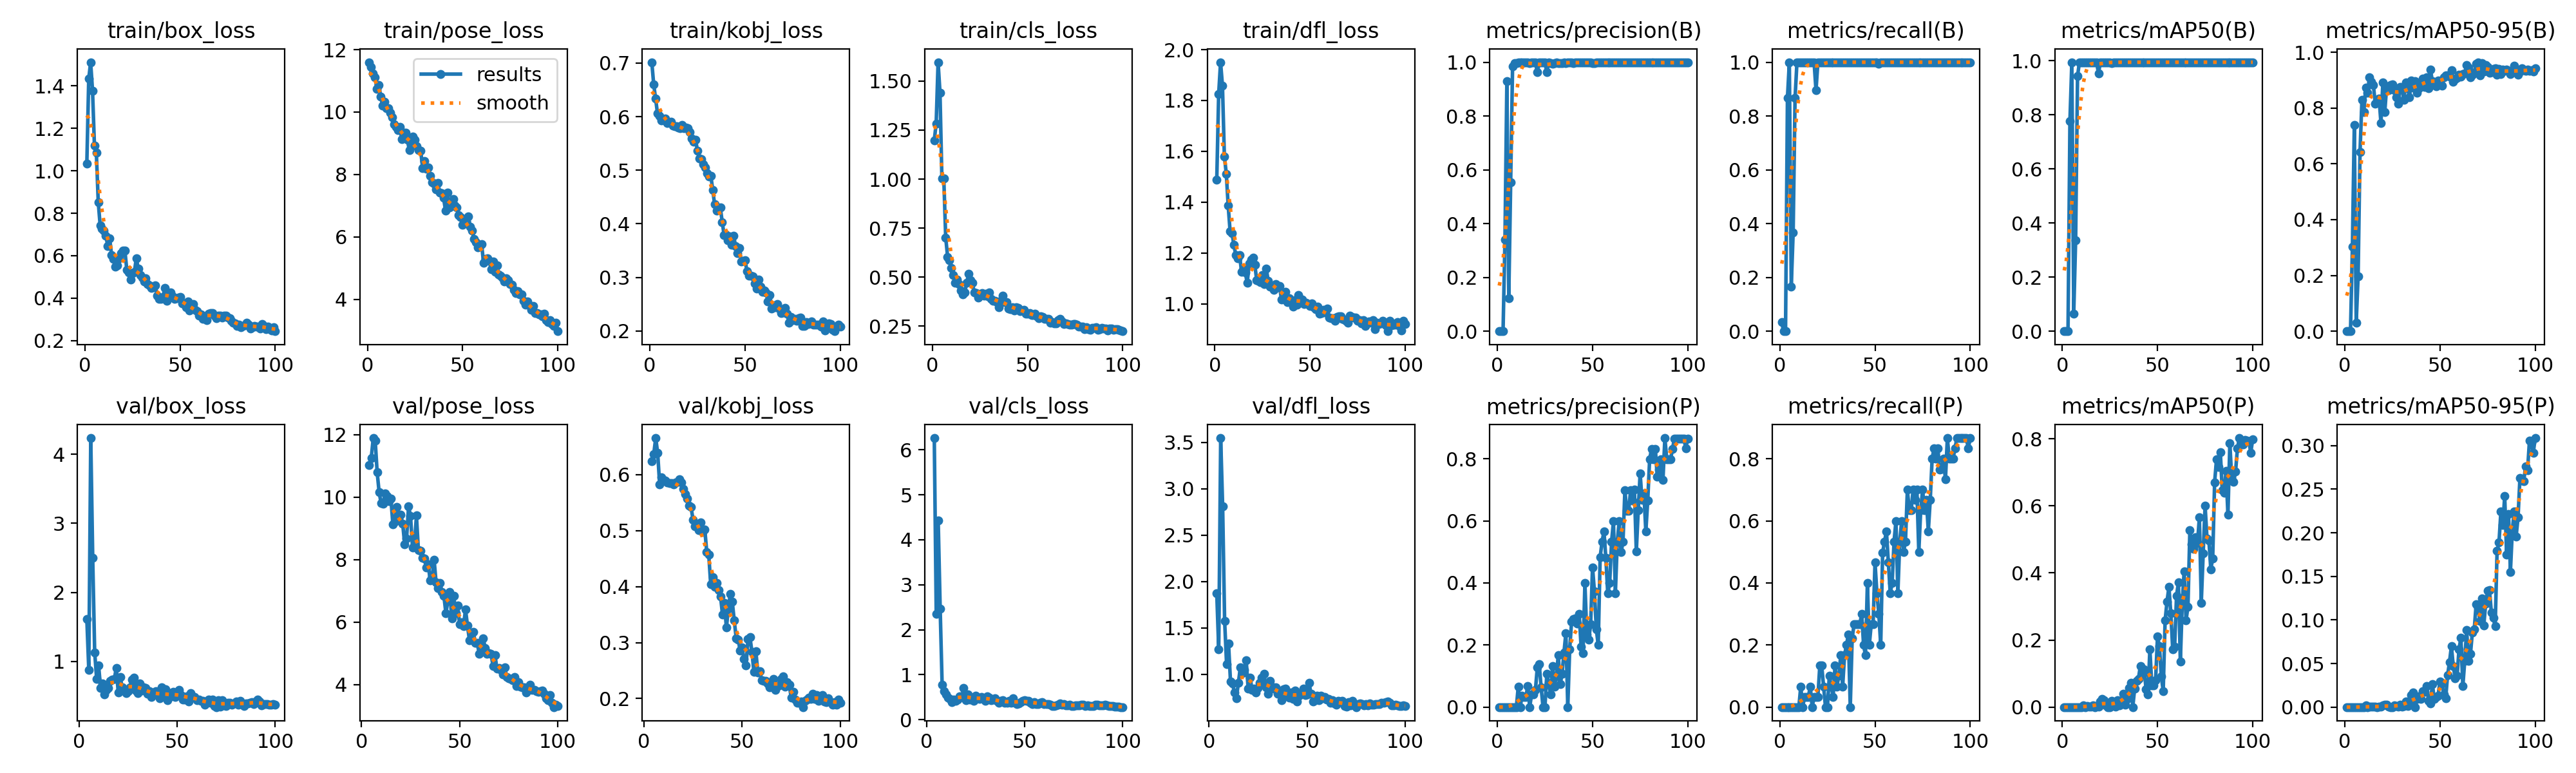


Preview: /content/runs/pose/football_pitch_keypoint_detector_colab/val_batch0_pred.jpg


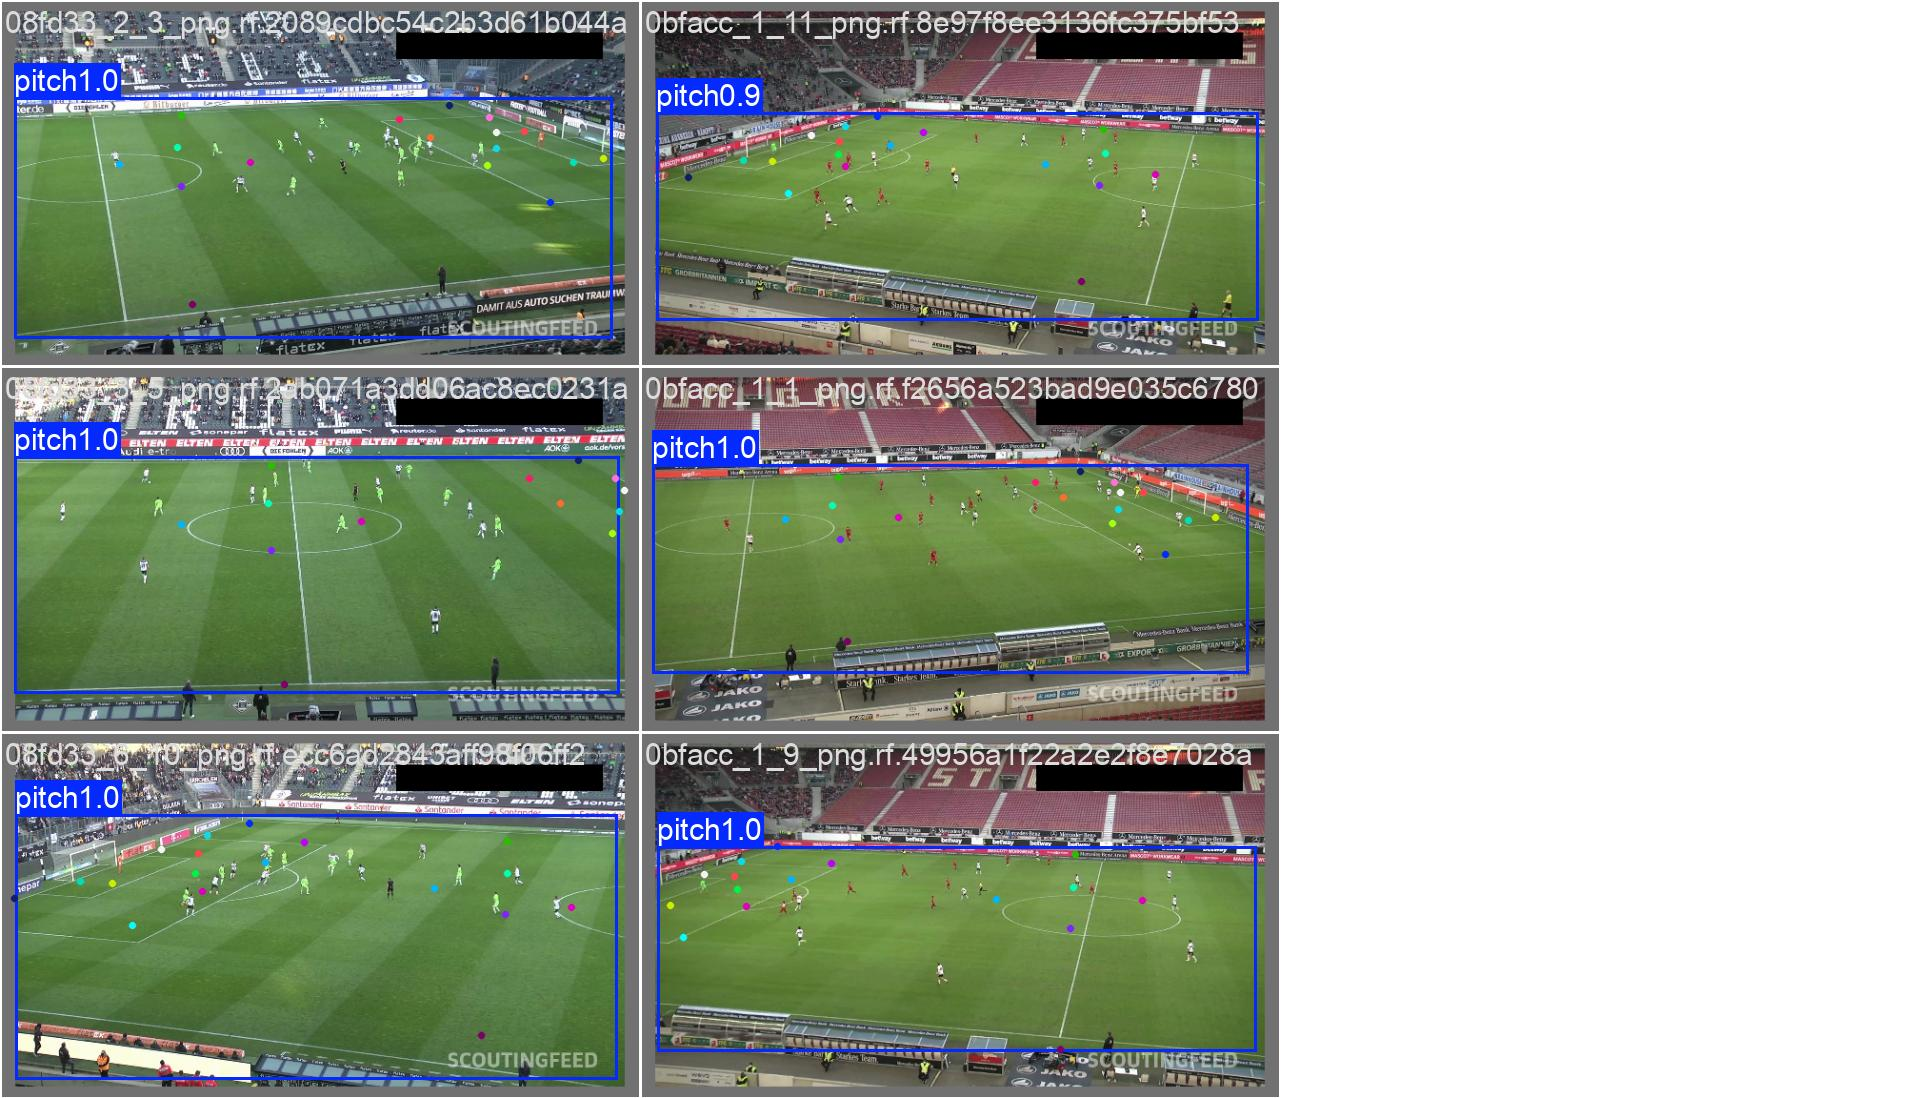

In [ ]:
RUN_DIR = Path(f"{HOME}/runs/pose/{RUN_NAME}")
print("RUN_DIR:", RUN_DIR)
!ls -lah {RUN_DIR}

for img_name in ['results.png', 'val_batch0_pred.jpg']:
    img_path = RUN_DIR / img_name
    if img_path.exists():
        print("\nPreview:", img_path)
        display(Image(filename=str(img_path), width=700))
    else:
        print("\nKhông tìm thấy:", img_path)

## 9. Validate model tốt nhất

In [ ]:
BEST_PT = Path(RUN_DIR) / "weights" / "best.pt"
print("BEST_PT:", BEST_PT)

!yolo task={TASK} mode=val \
    model={BEST_PT} \
    data={dataset.location}/data.yaml \
    imgsz={IMGSZ} \
    device={DEVICE}

BEST_PT: /content/runs/pose/football_pitch_keypoint_detector_colab/weights/best.pt
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x-pose summary (fused): 122 layers, 69,784,275 parameters, 0 gradients, 264.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3500.1±1241.7 MB/s, size: 240.8 KB)
val: Scanning /content/datasets/football-field-detection-12/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 5.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.7s
                   all         30         30      0.998          1      0.995      0.938      0.865      0.867      0.798      0.307
Speed: 3.1ms preprocess, 38.1ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/pose/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
# Copy model ra thư mục export
EXPORT_PATH = Path(EXPORT_DIR) / "football-pitch-detection.pt"
shutil.copy2(BEST_PT, EXPORT_PATH)

print("Đã copy model sang:", EXPORT_PATH)

# Nén kết quả
ZIP_PATH = f"{HOME}/train_pitch_keypoint_detector_colab_outputs.zip"
!cd {HOME} && zip -qr train_pitch_keypoint_detector_colab_outputs.zip runs/pose/{RUN_NAME} exported_models/football-pitch-detection.pt

print("ZIP output:", ZIP_PATH)

# Tự động trigger tải file nén về máy tính local
from google.colab import files
files.download(ZIP_PATH)

Đã copy model sang: /content/exported_models/football-pitch-detection.pt
ZIP output: /content/train_pitch_keypoint_detector_colab_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>